Mini Project: Visualizing Fashion-MNIST with an Autoencoder and t-SNE. Train an autoencoder in PyTorch to reconstruct Fashion-MNIST images, extract compressed latent representations, and use t-SNE to visualize how clothing categories organize in two-dimensional space. This project demonstrates unsupervised feature learning, latent-space analysis, dimensionality reduction, and cluster visualization.

Using device: cpu


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 246kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.2MB/s]


Epoch [1/10], Average Loss: 0.0589
Epoch [2/10], Average Loss: 0.0271
Epoch [3/10], Average Loss: 0.0228
Epoch [4/10], Average Loss: 0.0213
Epoch [5/10], Average Loss: 0.0200
Epoch [6/10], Average Loss: 0.0191
Epoch [7/10], Average Loss: 0.0184
Epoch [8/10], Average Loss: 0.0177
Epoch [9/10], Average Loss: 0.0171
Epoch [10/10], Average Loss: 0.0165

Autoencoder training complete.
Latent vector shape: (10000, 32)
t-SNE output shape: (3000, 2)


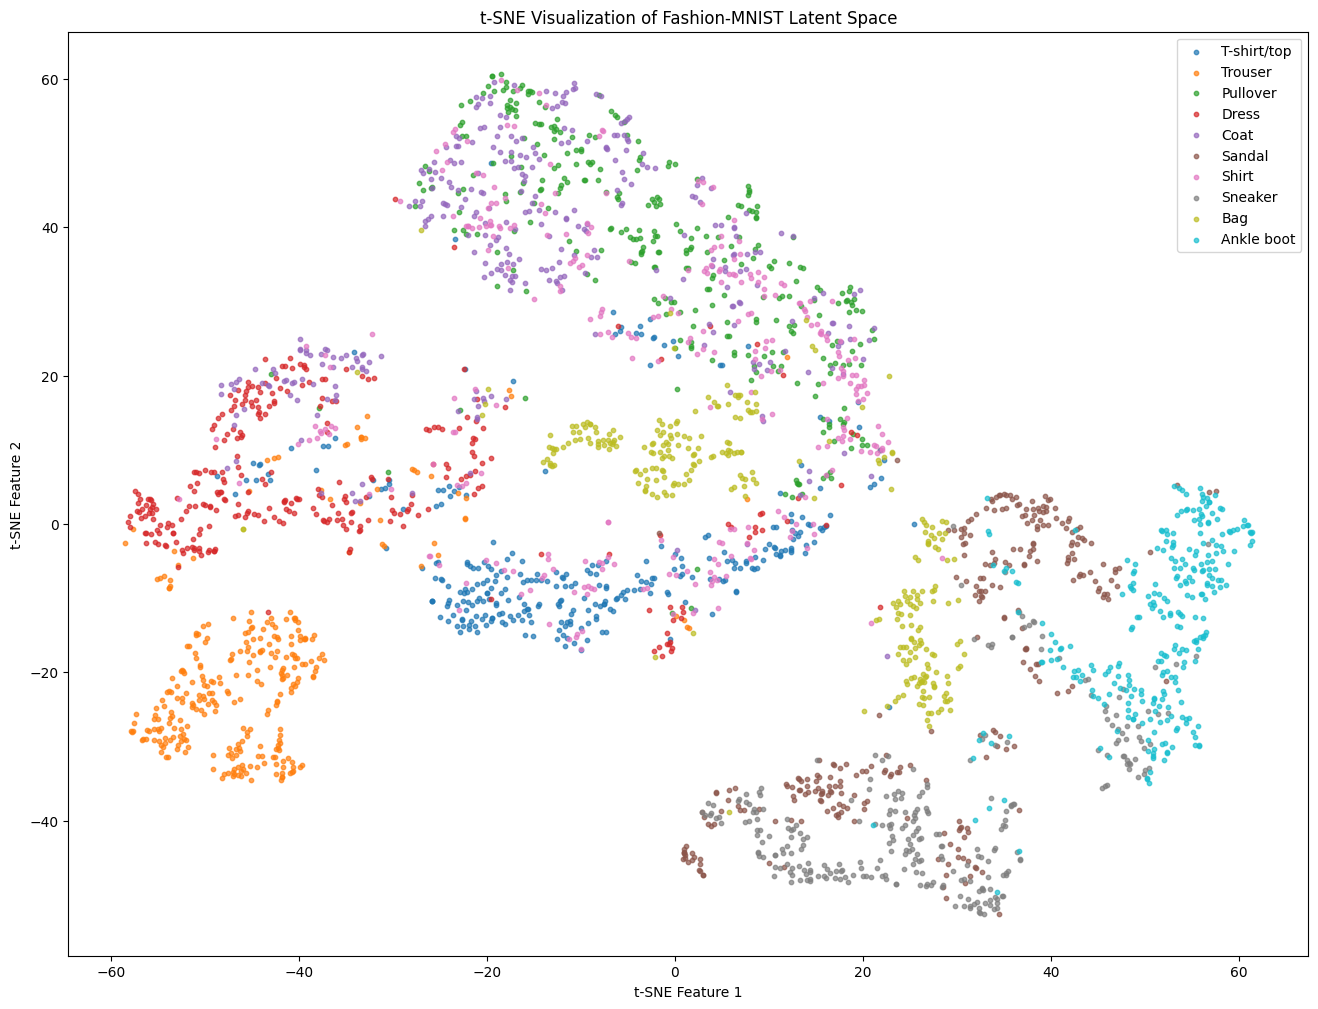


Successfully generated a t-SNE plot of the learned latent space.
Look for clusters of visually similar items such as sandals, sneakers, bags, and shirts.


In [1]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. Setup
# -------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------------------------------
# 2. Load and Prepare the Fashion-MNIST Dataset
# -------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# -------------------------------------------------------
# 3. Define the Autoencoder Model
# -------------------------------------------------------
class FashionAutoencoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# -------------------------------------------------------
# 4. Train the Autoencoder
# -------------------------------------------------------
model = FashionAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        reconstructed_images, _ = model(images)
        loss = criterion(reconstructed_images, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    average_loss = total_loss / len(train_loader.dataset)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Average Loss: {average_loss:.4f}"
    )

print("\nAutoencoder training complete.")

# -------------------------------------------------------
# 5. Extract Latent Vectors
# -------------------------------------------------------
model.eval()

all_latent_vectors = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        _, latent = model(images)

        all_latent_vectors.append(latent.cpu().numpy())
        all_labels.append(labels.numpy())

latent_vectors = np.concatenate(all_latent_vectors, axis=0)
labels = np.concatenate(all_labels, axis=0)

print(f"Latent vector shape: {latent_vectors.shape}")

# -------------------------------------------------------
# 6. Use t-SNE to Reduce the Latent Vectors to 2D
# -------------------------------------------------------
# To keep t-SNE fast for a textbook example, we visualize a subset.
num_points = 3000

latent_subset = latent_vectors[:num_points]
label_subset = labels[:num_points]

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    learning_rate="auto"
)

tsne_results = tsne.fit_transform(latent_subset)

print(f"t-SNE output shape: {tsne_results.shape}")

# -------------------------------------------------------
# 7. Plot the t-SNE Results
# -------------------------------------------------------
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(16, 12))

for i in range(10):
    indices = label_subset == i

    plt.scatter(
        tsne_results[indices, 0],
        tsne_results[indices, 1],
        label=class_names[i],
        alpha=0.7,
        s=10
    )

plt.legend()
plt.title("t-SNE Visualization of Fashion-MNIST Latent Space")
plt.xlabel("t-SNE Feature 1")
plt.ylabel("t-SNE Feature 2")
plt.show()

print("\nSuccessfully generated a t-SNE plot of the learned latent space.")
print("Look for clusters of visually similar items such as sandals, sneakers, bags, and shirts.")
